In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
x = np.array([[1],[2],[3],[4]])
y = np.array([2,4,6,8])


In [5]:
lin_reg = LinearRegression()
lin_reg.fit(x,y)
y_pred = lin_reg.predict(x)

w_lin = lin_reg.coef_
b_lin = lin_reg.intercept_

In [6]:
print("linear regression weight:")
print("MSE",mean_squared_error(y,y_pred))
print("R2 score",r2_score(y,y_pred))

linear regression weight:
MSE 0.0
R2 score 1.0


In [7]:
class RegularizedLinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.weights = None
        self.bias = 0

    def fit(self, X, y, regularization="l2"):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.n_iters):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            dw = (1/n_samples) * (X.T @ error)
            if regularization.lower() == "l1":
                dw += self.alpha * np.sign(self.weights)
            elif regularization.lower() == "l2":
                dw += self.alpha * self.weights
            else:
                raise ValueError("regularization must be l1 or l2")
            db = np.mean(error)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.weights + self.bias


In [8]:
model_l1 = RegularizedLinearRegression(learning_rate=0.01, n_iters=5000, alpha=0.1)
model_l1.fit(x, y, regularization="l1")
y_pred_l1 = model_l1.predict(x)
print("L1 (Lasso)")
print("Weight:", model_l1.weights)
print("Bias:", model_l1.bias)
print("MSE:", mean_squared_error(y, y_pred_l1))
print("R2:", r2_score(y, y_pred_l1))

model_l2 = RegularizedLinearRegression(learning_rate=0.01, n_iters=5000, alpha=0.1)
model_l2.fit(x, y, regularization="l2")
y_pred_l2 = model_l2.predict(x)
print("\nL2 (Ridge)")
print("Weight:", model_l2.weights)
print("Bias:", model_l2.bias)
print("MSE:", mean_squared_error(y, y_pred_l2))
print("R2:", r2_score(y, y_pred_l2))


L1 (Lasso)
Weight: [1.91992293]
Bias: 0.20022658937298313
MSE: 0.008015422178597569
R2: 0.9983969155642805

L2 (Ridge)
Weight: [1.85182644]
Bias: 0.37044599436061676
MSE: 0.027444254729815272
R2: 0.9945111490540369


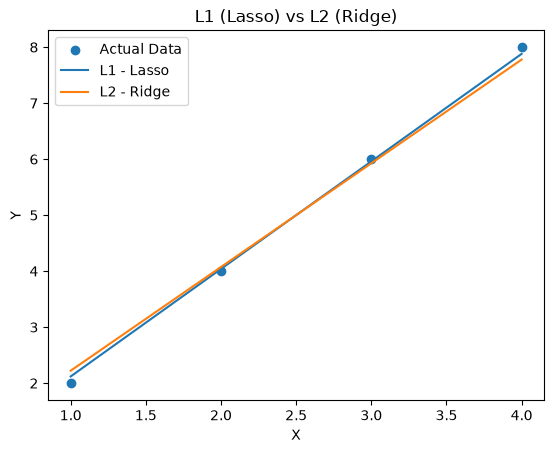

In [9]:
plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_pred_l1, label="L1 - Lasso")
plt.plot(x, y_pred_l2, label="L2 - Ridge")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("L1 (Lasso) vs L2 (Ridge)")
plt.legend()
plt.show()
